In [1]:
# Notebook 02: PCA Analysis
#
# Purpose:
# - Load merged county-level modeling data
# - Select PCA variables
# - Align feature direction for risk
# - Handle missing values
# - Standardize variables
# - Run PCA
# - Create county-level composite risk scores

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'pandas'

In [ ]:
BASE_DIR = Path.cwd().parent
model_file = BASE_DIR / "data" / "merged" / "gc_cpri_model_input.csv"

df = pd.read_csv(model_file)
df.head()

,county,registered_voters,total_ballots_cast,turnout_rate,absentee_rate,population_2023,poverty_rate,pct_less_hs,pct_bachelors,unemployment_rate,median_income,white_share,non_white_share,rural_urban_code,broadband_households
0,BALDWIN,207643,122542,0.5902,0.0634,253507.0,10.0,8.268600,32.797637,2.3,71704.0,0.922164,0.077836,3.0,"89,266"
1,CLARKE,19143,11993,0.6265,0.0604,22337.0,19.0,14.731304,15.426531,5.0,44906.0,0.594405,0.405595,9.0,"6,206"
2,CONECUH,9820,6105,0.6217,0.0785,11174.0,26.5,12.513843,13.129076,3.5,36106.0,0.594741,0.405259,9.0,"3,211"
3,ESCAMBIA,28268,15009,0.5310,0.0477,36558.0,21.3,17.467352,12.490686,3.1,47792.0,0.748884,0.251116,6.0,"10,114"
4,MOBILE,322535,176019,0.5457,0.0489,411640.0,16.3,10.991693,25.150224,3.1,54315.0,0.651520,0.348480,2.0,"139,490"


In [ ]:
candidate_features = [
    "poverty_rate",
    "unemployment_rate",
    "median_income",
    "pct_less_hs",
    "non_white_share",
    "rural_urban_code",
    "broadband_households"
]

pca_df = df[candidate_features].copy()
pca_df.head()

,poverty_rate,unemployment_rate,median_income,pct_less_hs,non_white_share,rural_urban_code
0,10.0,2.3,71704.0,8.268600,0.077836,3.0
1,19.0,5.0,44906.0,14.731304,0.405595,9.0
2,26.5,3.5,36106.0,12.513843,0.405259,9.0
3,21.3,3.1,47792.0,17.467352,0.251116,6.0
4,16.3,3.1,54315.0,10.991693,0.348480,2.0


In [5]:
pca_df.describe()

,poverty_rate,unemployment_rate,median_income,pct_less_hs,non_white_share,rural_urban_code
count,7.00000,7.000000,7.000000,7.000000,8.000000,7.000000
mean,18.70000,3.414286,50872.285714,13.096151,0.295416,6.428571
std,4.98832,0.949436,11021.269054,3.262040,0.111660,2.878492
min,10.00000,2.300000,36106.000000,8.268600,0.077836,2.000000
25%,17.50000,2.850000,46202.000000,11.153325,0.249161,4.500000
50%,19.00000,3.100000,47792.000000,12.513843,0.301769,8.000000
75%,20.20000,3.900000,54050.000000,15.558307,0.383832,8.500000
max,26.50000,5.000000,71704.000000,17.467352,0.405595,9.000000


In [ ]:
# poverty: higher poverty = higher risk
if pca_df["poverty_rate"].max() > 1:
    pca_df["poverty_rate"] = pca_df["poverty_rate"] / 100

# unemployment: higher unemployment = higher risk
if pca_df["unemployment_rate"].max() > 1:
    pca_df["unemployment_rate"] = pca_df["unemployment_rate"] / 100

# education: higher % less than HS = higher risk
if pca_df["pct_less_hs"].max() > 1:
    pca_df["pct_less_hs"] = pca_df["pct_less_hs"] / 100

# income: higher income = lower risk
pca_df["median_income"] = -1 * pca_df["median_income"]

# rural: higher = more rural = higher risk
pca_df["rural_urban_code"] = pca_df["rural_urban_code"]

# broadband: higher broadband access = lower risk
pca_df["broadband_households"] = -1 * pca_df["broadband_households"]

pca_df.head()

,poverty_rate,unemployment_rate,median_income,pct_less_hs,non_white_share,rural_urban_code
0,0.100,0.023,-71704.0,0.082686,0.077836,3.0
1,0.190,0.050,-44906.0,0.147313,0.405595,9.0
2,0.265,0.035,-36106.0,0.125138,0.405259,9.0
3,0.213,0.031,-47792.0,0.174674,0.251116,6.0
4,0.163,0.031,-54315.0,0.109917,0.348480,2.0


In [7]:
pca_df.isna().sum()

poverty_rate         1
unemployment_rate    1
median_income        1
pct_less_hs          1
non_white_share      0
rural_urban_code     1
dtype: int64

In [8]:
imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(
    imputer.fit_transform(pca_df),
    columns=pca_df.columns
)

X_imputed.head()

,poverty_rate,unemployment_rate,median_income,pct_less_hs,non_white_share,rural_urban_code
0,0.100,0.023,-71704.0,0.082686,0.077836,3.0
1,0.190,0.050,-44906.0,0.147313,0.405595,9.0
2,0.265,0.035,-36106.0,0.125138,0.405259,9.0
3,0.213,0.031,-47792.0,0.174674,0.251116,6.0
4,0.163,0.031,-54315.0,0.109917,0.348480,2.0


In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

In [10]:
corr = X_imputed.corr()
corr

,poverty_rate,unemployment_rate,median_income,pct_less_hs,non_white_share,rural_urban_code
poverty_rate,1.000000,0.385599,0.954210,0.567266,0.709186,0.695371
unemployment_rate,0.385599,1.000000,0.605978,0.624996,0.795550,0.552314
median_income,0.954210,0.605978,1.000000,0.630751,0.847121,0.734473
pct_less_hs,0.567266,0.624996,0.630751,1.000000,0.526169,0.490163
non_white_share,0.709186,0.795550,0.847121,0.526169,1.000000,0.506699
rural_urban_code,0.695371,0.552314,0.734473,0.490163,0.506699,1.000000


In [11]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [12]:
explained_variance = pd.DataFrame({
    "component": [f"PC{i+1}" for i in range(len(pca.explained_variance_ratio_))],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_variance": np.cumsum(pca.explained_variance_ratio_)
})

explained_variance

,component,explained_variance_ratio,cumulative_variance
0,PC1,0.705930,0.705930
1,PC2,0.126165,0.832095
2,PC3,0.086065,0.918160
3,PC4,0.075143,0.993303
4,PC5,0.004827,0.998130
5,PC6,0.001870,1.000000


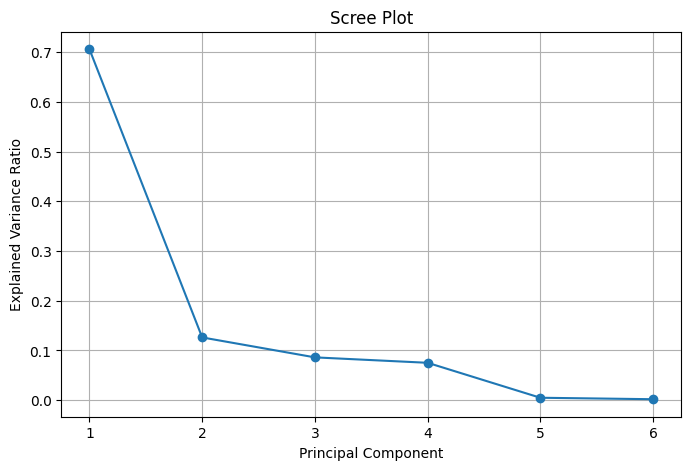

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(pca.explained_variance_ratio_) + 1),
    pca.explained_variance_ratio_,
    marker="o"
)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot")
plt.grid(True)
plt.show()

In [14]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=X_imputed.columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

loadings

,PC1,PC2,PC3,PC4,PC5,PC6
poverty_rate,0.422174,-0.518139,-0.054032,-0.274090,-0.254736,-0.640598
unemployment_rate,0.378301,0.664633,-0.117875,0.313382,-0.508843,-0.210067
median_income,0.465230,-0.259550,-0.151876,-0.153211,-0.356418,0.736628
pct_less_hs,0.365210,0.294594,0.745689,-0.423806,0.206579,0.038696
non_white_share,0.426732,0.219636,-0.569015,-0.169301,0.645106,-0.032516
rural_urban_code,0.383067,-0.295641,0.283355,0.771309,0.300529,0.018155


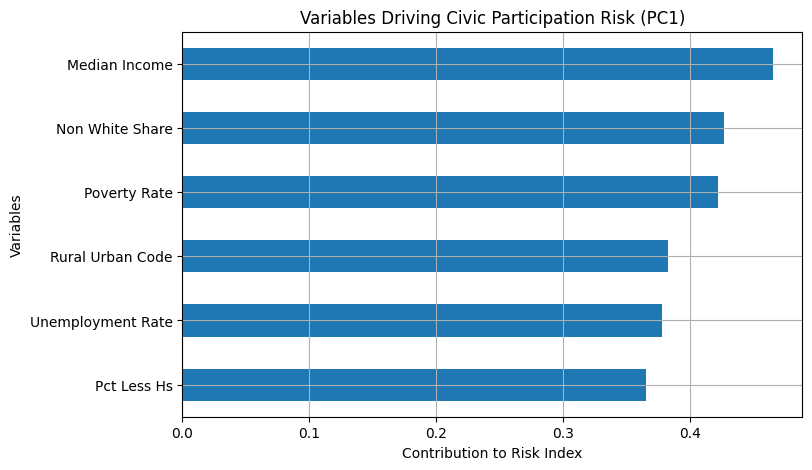

In [20]:
# PC1 Loadings Bar Chart

plt.figure(figsize=(8, 5))

# Format variable names
formatted_index = (
    loadings["PC1"]
    .sort_values()
    .index
    .str.replace("_", " ")     
    .str.title()              
)

# Plot using formatted labels
loadings["PC1"].sort_values().set_axis(formatted_index).plot(kind="barh")

plt.title("Variables Driving Civic Participation Risk (PC1)")
plt.xlabel("Contribution to Risk Index")
plt.ylabel("Variables")

plt.grid(True)

plt.show()

In [16]:
df["gc_cpri_score_raw"] = X_pca[:, 0]
df[["county", "gc_cpri_score_raw"]].head()

,county,gc_cpri_score_raw
0,BALDWIN,-4.420170
1,CLARKE,2.065602
2,CONECUH,2.252798
3,ESCAMBIA,0.553625
4,MOBILE,-1.290178


In [17]:
df["gc_cpri_score"] = (
    (df["gc_cpri_score_raw"] - df["gc_cpri_score_raw"].min()) /
    (df["gc_cpri_score_raw"].max() - df["gc_cpri_score_raw"].min())
) * 100

df[["county", "gc_cpri_score"]].head()

,county,gc_cpri_score
0,BALDWIN,0.000000
1,CLARKE,97.194711
2,CONECUH,100.000000
3,ESCAMBIA,74.536472
4,MOBILE,46.905542


In [18]:
df[["county", "gc_cpri_score"]].sort_values("gc_cpri_score", ascending=False).head(10)

,county,gc_cpri_score
2,CONECUH,100.000000
1,CLARKE,97.194711
5,MONROE,89.843050
3,ESCAMBIA,74.536472
7,TOTAL (ALL OF ALABAMA),66.344735
6,WASHINGTON,55.094972
4,MOBILE,46.905542
0,BALDWIN,0.000000


In [19]:
OUTPUT_DIR = BASE_DIR / "data" / "final"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df.to_csv(OUTPUT_DIR / "gc_cpri_scored_counties.csv", index=False)
loadings.to_csv(OUTPUT_DIR / "gc_cpri_pca_loadings.csv")
explained_variance.to_csv(OUTPUT_DIR / "gc_cpri_explained_variance.csv", index=False)